In [16]:
import os
import langchain
from dotenv import load_dotenv
load_dotenv()

# os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
from langchain_groq import ChatGroq

# os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = ChatGroq(model="openai/gpt-oss-safeguard-20b")


In [17]:
from langchain_tavily import TavilySearch

tavily_search_tool = TavilySearch(
    max_results = 3,
    topic = "general"
)

tavily_search_tool.invoke("What is the current AI News?")



{'query': 'What is the current AI News?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.crescendo.ai/news/latest-ai-news-and-updates',
   'title': 'Latest AI News and AI Breakthroughs that Matter Most: 2026 & 2025',
   'content': 'Summary: Apple has officially announced that a completely reimagined, AI-powered version of Siri is set to debut in 2026. This fundamental transformation will',
   'score': 0.752468,
   'raw_content': None},
  {'url': 'https://www.wsj.com/tech/ai?gaa_at=eafs&gaa_n=AWEtsqfzaZUEEGM_38sGjPXo7JddONJ-Ct0wV5uG0OY25lSde63FNClgMCI3&gaa_ts=6966189d&gaa_sig=f7DzIlTpAjy78exU2wN7yQ5mdPLmwx95MT86xm9JP82QPOgy_08MCtUbqUBP9LKJ8NMdbZBeqKgzJ3Xl9y_eBA%3D%3D',
   'title': 'Artificial Intelligence - Latest AI News and Analysis - WSJ.com',
   'content': 'Artificial Intelligence · OpenAI Set to Run Another Super Bowl Ad as Chatbot Competition Heats Up · Alphabet Becomes Newest $4 Trillion Company, Joining Nvidia.',
   'score': 0.692

In [18]:
from langchain.tools import tool

@tool("calculator", description = "Performs arithmetics calculations. Use this for any math problems.")

def calc(expression: str) -> str:
    """Evaluate a mathematical expresion."""
    return str(eval(expression))

In [19]:
from  langchain.agents import create_agent

agent = create_agent(model,[tavily_search_tool, calc] )

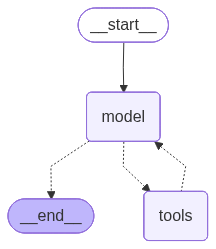

In [20]:
agent

In [22]:
user_input = "What is the current news of 13th January 2026 about USA and Iran"

for step in agent.stream(
    {"messages": user_input},
    stream_mode="values"
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is the current news of 13th January 2026 about USA and Iran
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_805f151e-a9bb-4845-af8c-2099ed2e0263)
 Call ID: fc_805f151e-a9bb-4845-af8c-2099ed2e0263
  Args:
    query: USA Iran January 13 2026 news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "USA Iran January 13 2026 news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.ncr-iran.org/en/news/iran-news-in-brief-news/iran-news-in-brief-january-13-2026/", "title": "Iran News in Brief – January 13, 2026 - NCRI", "content": "Tuesday, January 13, 2026\n\nEN FR DE IT AR ES AL [...] Facebook     Pinterest     RSS     Twitter     Vimeo     Youtube [...] citizens crushed under t

In [25]:
agent.invoke({"messages": "What is the bangla date of today in Bangladesh?"})

{'messages': [HumanMessage(content='What is the bangla date of today in Bangladesh?', additional_kwargs={}, response_metadata={}, id='93db2166-4375-4f27-88c4-ae70576af34f'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer: "What is the bangla date of today in Bangladesh?" That requires conversion from Gregorian date to Bangla (Bengali) calendar, likely the Bengali calendar (Bangla calendar). Today is 2026-01-13 (current date). We need to give the Bangla date. The Bengali calendar is a solar calendar based on the tropical year, with months: Baishakh, Jyoishtho, Ashar, Srabon, Bhadro, Ashwin, Kartik, Agrahayan, Poush, Magh, Falgun, Choitro. The Bengali year is usually 593 years ahead of Gregorian? Actually Bengali year is roughly 593 years ahead? Wait, the Bengali calendar\'s year 2023 AD is 1429 BS? Let\'s recall: The Bengali calendar year started in 593 AD? The Bengali year 1429 corresponds to 2023? Actually the Bengali year 1429 started in 2023? Let\